<a href="https://colab.research.google.com/github/Saleh-Furqan/OCR_playground/blob/benchmark-testing/Copy_of_text_representation_tutorial1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Introduction to Text Preprocessing

Text preprocessing is the method of cleaning and structuring text data prior to analysis. It encompasses various techniques such as tokenization, stemming, lemmatization, and more, which are vital for simplifying and normalizing text data for effective processing by algorithms.

**Why is Text Preprocessing Important?**

Consistency: Standardizes text data for uniformity.

Efficiency: Reduces complexity, enhancing NLP model performance.

Accuracy: Improves reliability and precision of analysis.![image.png](https://miro.medium.com/v2/resize:fit:720/format:webp/1*pt47uCcCn3X7XNYQg1dghw.png)



**Setting Up NLTK**

Before starting with text preprocessing, install NLTK using Python’s package manager:

In [ ]:
! pip install nltk
! pip install gensim

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 48.5 MB/s eta 0:00:00


Next, download essential datasets and tokenizers:

In [ ]:
import nltk
nltk.download('popular')
nltk.download('punkt_tab')

[nltk_data] Downloading collection 'popular'
[nltk_data]    | 
[nltk_data]    | Downloading package cmudict to /root/nltk_data...
[nltk_data]    |   Unzipping corpora/cmudict.zip.
[nltk_data]    | Downloading package gazetteers to /root/nltk_data...
[nltk_data]    |   Unzipping corpora/gazetteers.zip.
[nltk_data]    | Downloading package genesis to /root/nltk_data...
[nltk_data]    |   Unzipping corpora/genesis.zip.
[nltk_data]    | Downloading package gutenberg to /root/nltk_data...
[nltk_data]    |   Unzipping corpora/gutenberg.zip.
[nltk_data]    | Downloading package inaugural to /root/nltk_data...
[nltk_data]    |   Unzipping corpora/inaugural.zip.
[nltk_data]    | Downloading package movie_reviews to
[nltk_data]    |     /root/nltk_data...
[nltk_data]    |   Unzipping corpora/movie_reviews.zip.
[nltk_data]    | Downloading package names to /root/nltk_data...
[nltk_data]    |   Unzipping corpora/names.zip.
[nltk_data]    | Downloading package shakespeare to /root/nltk_data...
[nlt

True

**Tokenization**

Tokenization splits text into smaller units, like words or sentences, and is a foundational step in text preprocessing.

To tokenize words, use NLTK’s word_tokenize method:

In [ ]:
from nltk.tokenize import word_tokenize

text = "Sentiment analysis is a natural language processing task that detects emotions and opinions expressed in text."
words = word_tokenize(text)
print(words)

['Sentiment', 'analysis', 'is', 'a', 'natural', 'language', 'processing', 'task', 'that', 'detects', 'emotions', 'and', 'opinions', 'expressed', 'in', 'text', '.']


For sentence tokenization, sent_tokenize is used:

In [ ]:
from nltk.tokenize import sent_tokenize

sentences = sent_tokenize(text + " I love CSCI3280.")
print(sentences)

['Sentiment analysis is a natural language processing task that detects emotions and opinions expressed in text.', 'I love CSCI3280.']


**Cleaning Text Data**

Cleaning involves removing irrelevant characters such as punctuation, numbers, and special symbols to enhance data quality.

Removing Punctuation and Numbers
Utilize Python’s regular expressions for this task:

**\w**: Matches any "word" character, which includes:

Letters (a-z, A-Z), Digits (0-9), Underscores (_)

In essence, \w matches alphanumeric characters and underscores.

**\s**: Matches any whitespace character, which includes:

Space ( ), Tab (\t), Newline (\n), Carriage return (\r), Form feed (\f)

^(caret): means not

In [ ]:
import re

#This line of code removes all characters from the string text that are not a word character or a whitespace.
cleaned_text = re.sub(r'[^\w\s]', '', text)
print(cleaned_text)

Sentiment analysis is a natural language processing task that detects emotions and opinions expressed in text


**Case Normalization**

Case normalization ensures consistency by converting all text to the same case, typically lowercase:

In [ ]:
lowercase_cleaned_text = cleaned_text.lower()
print(lowercase_cleaned_text)

sentiment analysis is a natural language processing task that detects emotions and opinions expressed in text


**Stop words removing**

In [ ]:
from nltk.corpus import stopwords


stop_words = set(stopwords.words('english'))

word_tokens = word_tokenize(lowercase_cleaned_text)
# converts the words in word_tokens to lower case and then checks whether
#they are present in stop_words or not
filtered_sentence = [w for w in word_tokens if not w.lower() in stop_words]
#with no lower case conversion
filtered_sentence = []

for w in word_tokens:
    if w not in stop_words:
        filtered_sentence.append(w)

print(word_tokens)
print(filtered_sentence)

['sentiment', 'analysis', 'is', 'a', 'natural', 'language', 'processing', 'task', 'that', 'detects', 'emotions', 'and', 'opinions', 'expressed', 'in', 'text']
['sentiment', 'analysis', 'natural', 'language', 'processing', 'task', 'detects', 'emotions', 'opinions', 'expressed', 'text']


**Stemming and Lemmatization**

Stemming and lemmatization reduce words to a base or root form, aiding in normalizing text data.

**Stemming** is a rule-based process of removing suffixes (or prefixes in some cases) from a word to reduce it to its base or root form.

It is a heuristic method and often ignores the linguistic meaning of the word.

**Method:** Uses simple rules or algorithms to chop off affixes (e.g., "ing," "ed," "s").

**Output:** Produces a "stem" that may not be a valid word in the language.

**Efficiency:** Faster and less computationally expensive.

**Accuracy:** Can be less accurate and may result in stems that are not meaningful.

**Example:**

Words: "running," "runner," "runs"

Stem: "run"

Words: "studies," "studying"

Stem: "studi"



In [ ]:
from nltk.stem import PorterStemmer

stemmer = PorterStemmer()
stemmed_words = [stemmer.stem(word) for word in words]
print(stemmed_words)

['sentiment', 'analysi', 'is', 'a', 'natur', 'languag', 'process', 'task', 'that', 'detect', 'emot', 'and', 'opinion', 'express', 'in', 'text', '.']


**Lemmatization**

Lemmatization reduces a word to its base or dictionary form (lemma) while considering its meaning and grammatical role. It relies on vocabulary and morphological analysis.

**Method:** Uses dictionaries or linguistic rules to find the base form (lemma) of a word.

**Output:** Produces a valid word in the language.

**Efficiency:** Slower and more computationally intensive because it considers the context.

**Accuracy:** More accurate as it ensures the resulting lemma is meaningful.

**Example:**

Words: "running," "runner"

Lemma: "run"

Words: "better"

Lemma: "good" (requires semantic understanding)

In [ ]:
from nltk.stem import WordNetLemmatizer
nltk.download('wordnet')

lemmatizer = WordNetLemmatizer()
lemmatized_words = [lemmatizer.lemmatize(word) for word in words]
print(lemmatized_words)

[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


['Sentiment', 'analysis', 'is', 'a', 'natural', 'language', 'processing', 'task', 'that', 'detects', 'emotion', 'and', 'opinion', 'expressed', 'in', 'text', '.']


# Represent Text with Vectors

**What is Word Embedding?**

In very simple terms, Word Embeddings are the texts converted into numbers and there may be different numerical representations of the same text. But before we dive into the details of Word Embeddings, the following question should come to mind:

Why do we need Word Embeddings?
As we know that many Machine Learning algorithms and almost all Deep Learning Architectures are not capable of processing strings or plain text in their raw form. In a broad sense, they require numerical numbers as inputs to perform any sort of task, such as classification, regression, clustering, etc. Also, from the huge amount of data that is present in the text format, it is imperative to extract some knowledge out of it and build any useful applications.

In short, we can say that to build any model in machine learning or deep learning, the final level data has to be in numerical form because models don’t understand text or image data directly as humans do.

![image.png](https://www.baeldung.com/wp-content/uploads/sites/4/2023/03/one-hot-encoding.png)

**One Hot Encoding**

One-Hot Encoding is a technique used to represent words as vectors. Each word in the vocabulary is converted into a binary vector with a length equal to the size of the vocabulary.

![image.png](https://miro.medium.com/v2/resize:fit:1400/0*4QWLdmNkB87GPi_S)

In [ ]:
# Step 1: Define the Sample Texts
documents = [
    "I love natural language processing",
    "Natural language processing is fascinating",
    "I love programming and data science"
]


# Step 2: Tokenize each document by lowercasing and splitting by spaces
tokenized_docs = [doc.lower().split() for doc in documents]

# Print each tokenized document
for i, tokens in enumerate(tokenized_docs, 1):
    print(f"Document {i}: {tokens}")

all_tokens = [word for tokens in tokenized_docs for word in tokens]

# Step 3: Create a Vocabulary
vocabulary = sorted(set(all_tokens))
print("vocabulary: ", vocabulary)

Document 1: ['i', 'love', 'natural', 'language', 'processing']
Document 2: ['natural', 'language', 'processing', 'is', 'fascinating']
Document 3: ['i', 'love', 'programming', 'and', 'data', 'science']
vocabulary:  ['and', 'data', 'fascinating', 'i', 'is', 'language', 'love', 'natural', 'processing', 'programming', 'science']


In [ ]:
import pandas as pd
from sklearn.feature_extraction.text import CountVectorizer

# Initialize the CountVectorizer for One-Hot Encoding
vectorizer = CountVectorizer(binary=True)

# Fit and transform the documents
one_hot_matrix = vectorizer.fit_transform(documents)

# Convert to DataFrame
one_hot_df = pd.DataFrame(one_hot_matrix.toarray(), columns=vectorizer.get_feature_names_out())

# Display the result
print(one_hot_df)

# Add a column for document labels
one_hot_df.insert(0, 'Document', [f'Document {i+1}' for i in range(len(documents))])

# Display the DataFrame in tabular form
display(one_hot_df)

   and  data  fascinating  is  language  love  natural  processing  \
0    0     0            0   0         1     1        1           1   
1    0     0            1   1         1     0        1           1   
2    1     1            0   0         0     1        0           0   

   programming  science  
0            0        0  
1            0        0  
2            1        1  


,Document,and,data,fascinating,is,language,love,natural,processing,programming,science
0,Document 1,0,0,0,0,1,1,1,1,0,0
1,Document 2,0,0,1,1,1,0,1,1,0,0
2,Document 3,1,1,0,0,0,1,0,0,1,1


**Bag of Words (BoW)**

The Bag of Words (BoW) model is a commonly used technique in sentiment analysis for converting text data into numerical representations. It represents a document as a “bag” of its constituent words, ignoring grammar and word order. To use the BoW model, we first take a paragraph of text that we want to analyze for sentiment. We then break down the paragraph into its individual words, treating it as a collection or “bag” of these words.

Next, we disregard grammar rules and word order. We focus solely on the words themselves and their frequency within the paragraph. We count how many times each word appears and create a list of unique words along with their respective counts.

![image.png](https://miro.medium.com/v2/resize:fit:1322/format:webp/0*cf1wq8eIix-Z2qIf.png)

In [ ]:
# Define the documents
documents = [
    "I love programming in Python. Python programming is great.",
    "Python programming is fun. Programming is very interesting.",
    "I love learning new programming languages. Programming is exciting."
]

# Initialize the CountVectorizer for Bag of Words with frequency counts
vectorizer = CountVectorizer(binary=False)

# Fit and transform the documents
bow_matrix = vectorizer.fit_transform(documents)

# Convert to DataFrame
bow_df = pd.DataFrame(bow_matrix.toarray(), columns=vectorizer.get_feature_names_out())

# Add a column for document labels
bow_df.insert(0, 'Document', [f'Document {i+1}' for i in range(len(documents))])

# Display the DataFrame in tabular form
display(bow_df)

,Document,exciting,fun,great,in,interesting,is,languages,learning,love,new,programming,python,very
0,Document 1,0,0,1,1,0,1,0,0,1,0,2,2,0
1,Document 2,0,1,0,0,1,2,0,0,0,0,2,1,1
2,Document 3,1,0,0,0,0,1,1,1,1,1,2,0,0


**Word Embedding**

is a technique used in Natural Language Processing (NLP) to represent words as continuous vectors of real numbers in a lower-dimensional space. These vectors capture the semantic meaning of words, allowing words with similar meanings to have similar vector representations. Word embeddings are learned from large text corpora and enable models to understand the context and relationships between words more effectively than traditional methods like one-hot encoding. Popular word embedding methods include Word2Vec, GloVe, and FastText.

Techniques :

Predictive Models: Word2Vec, FastText

Count-based Models: GloVe

Contextualized Models: ELMo, BERT, GPT


**Continuous Bag of Words(CBOW)** is a representative Word2Vec architecture.

![image.png](https://eavelardev.github.io/_images/02740.jpg)

![image.png](https://eavelardev.github.io/_images/04132.jpg)

![image.png](https://eavelardev.github.io/_images/06613.jpg)

![image.png](https://eavelardev.github.io/_images/07212.jpg)


In [ ]:
from gensim.models import Word2Vec
from nltk.tokenize import word_tokenize

# Sample corpus (list of sentences)
sentences = [
    "I love natural language processing.",
    "Natural language processing is fun.",
    "I enjoy learning about data science.",
    "Machine learning is a part of data science."
]

# Tokenize the sentences
tokenized_sentences = [word_tokenize(sentence.lower()) for sentence in sentences]

# Train the Word2Vec model
model_word2vec = Word2Vec(sentences=tokenized_sentences, vector_size=100, window=5, min_count=1, sg=0)  # CBOW model

# Get the vector for a specific word
word_vector = model_word2vec.wv['data']

# Print the word vector for 'data' (first 5 dimensions)
print(f"Word Vector for 'data': {word_vector[:5]}")

# Find similar words to 'data'
similar_words = model_word2vec.wv.most_similar('data')
print("\nWords similar to 'data':", similar_words)

Word Vector for 'data': [ 9.4563962e-05  3.0773198e-03 -6.8126451e-03 -1.3754654e-03
  7.6685809e-03]

Words similar to 'data': [('i', 0.1991206258535385), ('a', 0.17267344892024994), ('is', 0.1701759696006775), ('language', 0.145950585603714), ('processing', 0.06408757716417313), ('machine', 0.046526189893484116), ('natural', -0.002780967392027378), ('learning', -0.013495995663106441), ('love', -0.016904227435588837), ('fun', -0.01963859423995018)]


**Load a pre-trained word2vec model with nltk**

In [ ]:
from nltk.data import find
import gensim

nltk.download('word2vec_sample')

word2vec_sample = str(find('models/word2vec_sample/pruned.word2vec.txt'))
model = gensim.models.KeyedVectors.load_word2vec_format(word2vec_sample, binary=False)

[nltk_data] Downloading package word2vec_sample to /root/nltk_data...
[nltk_data]   Unzipping models/word2vec_sample.zip.


In [ ]:
print(len(model['university']))
print(model.most_similar(positive=['university'], topn = 3))

300
[('universities', 0.7003918290138245), ('faculty', 0.6780906915664673), ('undergraduate', 0.6587096452713013)]


Visualize the word vectors in 2D plotting.

fawn
deferment
Debts
Poetry
woods
clotted
hanging
hastily
comically
localized
spidery
disobeying
Adjusting
originality
Journey
mutinies
Western
alphabetic
Gravesend
Elec
slothful
wracked
Valle
Famed
stipulate
pigment
appropriation
rawhide
strictest
screaming
wooded
liaisons
broiler
wooden
Pergamon
Loeb
Sack
broiled
circuitry
deferments
resounds
Colonialism
gaskets
scrapes
precocity
Shocked
feasibility
miniatures
deadheads
mortgages


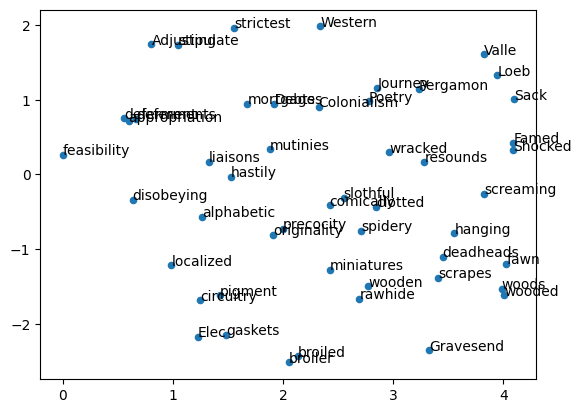

In [ ]:
import numpy as np
labels = []
count = 0
max_count = 50
X = np.zeros(shape=(max_count,len(model['university'])))

for term in list(model.index_to_key):
    print(term)
    X[count] = model[term]
    labels.append(term)
    count+= 1
    if count >= max_count: break

# It is recommended to use PCA first to reduce to ~50 dimensions
from sklearn.decomposition import PCA
pca = PCA(n_components=50)
X_50 = pca.fit_transform(X)

# Using TSNE to further reduce to 2 dimensions
from sklearn.manifold import TSNE
model_tsne = TSNE(n_components=2, random_state=0)
Y = model_tsne.fit_transform(X_50)

# Show the scatter plot
import matplotlib.pyplot as plt
plt.scatter(Y[:,0], Y[:,1], 20)

# Add labels
for label, x, y in zip(labels, Y[:, 0], Y[:, 1]):
    plt.annotate(label, xy = (x,y), xytext = (0, 0), textcoords = 'offset points', size = 10)

plt.show()